<a href="https://colab.research.google.com/github/bhattacharyasubhajit1632-maker/CMS-activities-and-muon-lifetime/blob/main/Copy_of_activity01_CMS_dimuons.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# How to edit and save this notebook to your personal Google Drive

If you try to run code in this notebook, you will be unable to as you are not the owner. Instead, you should first make a copy.

To copy this notebook to your Google Drive
* Select **File** (from the menu at the top) to get the drop-down options.
* Select **Save a copy in Drive**.

This will automatically open the copy in a new tab for you to work in. This new notebook will be saved into a folder on your personal Drive called *Colab Notebooks*.

After you do this, you will be able to edit and run the notebook and save your changes.

Still stumped? Check out <a href="https://www.youtube.com/watch?v=qaJ2UpMPXKk"> this video</a> for help or the **Documentation and help** section of the Particle Physics Playground.

# Looking at the dimuon spectrum over a wide energy range

<h3>Learning goals</h3>
<ul>
    <li>Relativistic kinematics.
    <li>Mesons.
</ul>

<b>Background</b>

To determine the mass ($m$) of a particle you need to know the 4-momenta of the particles ($\mathbf{P}$) that are detected after the collision: the energy ($E$), the momentum in the x direction ($p_x$), the momentum in the y direction ($p_y$), the momentum in the z direction ($p_z$).

$$\mathbf{P} = (E,p_x,p_y,p_z)$$


\begin{equation*} m = \sqrt{E^2-(p_x^2+p_y^2 + p_z^2)} \end{equation*}

Some particles are very unstable and decay (turn into) to two or more other particles. In fact, they can decay so quickly, that they never interact with your detector! Yikes!

However, we can reconstruct the parent particle (sometimes referred to as <b>the initial state particle</b>) and its 4-momentum by adding the 4-momenta of the child particles (sometimes referred to as <b>the decay products</b>).

$$\mathbf{P_{\rm parent}} = \mathbf{P_{\rm child 0}} + \mathbf{P_{\rm child 1}} + \mathbf{P_{\rm child 2}} + ...$$



which breaks down into...

$$E_{\rm parent} = E_{\rm child 0} + E_{\rm child 1} + E_{\rm child 2} + ...$$

$$p_{\rm x parent} = p_{\rm x child 0} + p_{\rm x child 1} + p_{\rm x child 2} + ...$$

$$p_{\rm y parent} = p_{\rm y child 0} + p_{\rm y child 1} + p_{\rm y child 2} + ...$$

$$p_{\rm z parent} = p_{\rm z child 0} + p_{\rm y child 1} + p_{\rm z child 2} + ...$$


<b>Let's code!</b>

Here is some very, very basic starter code. It reads in data from the CMS experiment.

If you haven't already, you will want to go through the <a href="https://colab.research.google.com/drive/1TFvNoq-i8isZoAwnZubRnNM0CrMGXUmP">CMS data model</a> (also included when you cloned this directory) exercise so you know how to pull out the relevant information.

The following example runs with 1000 events that are included with this repository. To better see the full phyiscs, you can download a bigger file, <code>dimuons_100k.dat</code>. To download this file, see the <a href="https://colab.research.google.com/drive/174AUxy9qTqQ1XndbJW_Wryz9m95QZRIk">download_more_data</a> exercise, also included in this repository.

<b>NOTE: If you are getting an error saying that there is no module "pps_tools", go to Runtime, and then select Restart runtime. Also make sure that your runtime type is Python 3. </b>

In [10]:
###### This cell need only be run once per session ##############
###### Make sure your runtime type is Python 3 #########

# Import h5hep from Github. This is to allow us to read these
# particular files.
!pip install git+https://github.com/mattbellis/h5hep.git

# Import custom tools package from Github. These are some simple accessor functions
# to make it easier to work with these data files.
!pip install git+https://github.com/mattbellis/particle_physics_simplified.git

import pps_tools as pps
import h5hep

  Cloning https://github.com/mattbellis/h5hep.git to /tmp/pip-req-build-0f09meq4
  Running command git clone --filter=blob:none --quiet https://github.com/mattbellis/h5hep.git /tmp/pip-req-build-0f09meq4
  Resolved https://github.com/mattbellis/h5hep.git to commit d9adc7dc7f7e3a3ec60671c731bf74a5f83e4e30
  Preparing metadata (setup.py) ... done
  Cloning https://github.com/mattbellis/particle_physics_simplified.git to /tmp/pip-req-build-0t658xy1
  Running command git clone --filter=blob:none --quiet https://github.com/mattbellis/particle_physics_simplified.git /tmp/pip-req-build-0t658xy1
  Resolved https://github.com/mattbellis/particle_physics_simplified.git to commit 85ec828661b39c6c08caa7625a584a76f473ee2a
  Preparing metadata (setup.py) ... done


In [11]:
###### This cell need only be run once per session ############################

# Fetch data file
pps.download_from_drive('dimuons_100k.hdf5')

In [12]:
# open and read data file
infile = 'data/dimuons_100k.hdf5'
collisions = pps.get_collisions(infile,experiment='CMS',verbose=False)


Building a simplified interface to the events...

Building the indices...
Built the indices!
Data is read in and input file is closed.
Reading in event  0
Reading in event  10000
Reading in event  20000
Reading in event  30000
Reading in event  40000
Reading in event  50000
Reading in event  60000
Reading in event  70000
Reading in event  80000
Reading in event  90000


<h2><font color="red">Challenge!</font></h2>

Use the sample code to find the mass of the particle that the two muons came from (parent particle).

To do this, you will need to loop over all pairs of muons for each collision, sum their 4-momenta (energy, px, py, and pz) and then use that to calculate the invariant mass.

Do this for all possible pairs and in addition, break it down so that you calculate the invariant mass for the cases where:
* Both muons are positively charged.
* Both muons are negatively charged.
* The muons have opposite charges.

Be careful. Some collisions may have more than 2 muons, so write your code such that it calculates all possible pairs of muons in a given collisions. For example, if there are 3 muons in a collision, there are 3 possible pairs that you can make.

<i>Hint!</i>

It is very likely that a particle exists where there is a peak in the data. However, this is not always true.
A peak in the data is most likely the mass of a particle. You can look at the approximate mass to figure out which particle
is found in the data.

Your histogram should look something like the following sketch. The value of the peaks should be the mass of a particle. You should be able to find two particles in their ground state. <a href="http://en.wikipedia.org/wiki/J/psi_meson">Check your answer for the first particle!</a> <a href="http://en.wikipedia.org/wiki/Upsilon_meson">Check your answer for the second particle!</a>

In [13]:
from IPython.display import Image
Image(url='https://raw.githubusercontent.com/particle-physics-playground/playground/master/activities/images/dimuons_sketch.jpeg')

  Cloning https://github.com/mattbellis/h5hep.git to /tmp/pip-req-build-ai182tb0
  Running command git clone --filter=blob:none --quiet https://github.com/mattbellis/h5hep.git /tmp/pip-req-build-ai182tb0
  Resolved https://github.com/mattbellis/h5hep.git to commit d9adc7dc7f7e3a3ec60671c731bf74a5f83e4e30
  Preparing metadata (setup.py) ... done
  Cloning https://github.com/mattbellis/particle_physics_simplified.git to /tmp/pip-req-build-y65gi15u
  Running command git clone --filter=blob:none --quiet https://github.com/mattbellis/particle_physics_simplified.git /tmp/pip-req-build-y65gi15u
  Resolved https://github.com/mattbellis/particle_physics_simplified.git to commit 85ec828661b39c6c08caa7625a584a76f473ee2a
  Preparing metadata (setup.py) ... done

Building a simplified interface to the events...

Building the indices...
Built the indices!
Data is read in and input file is closed.
Reading in event  0
Reading in event  10000
Reading in event  20000
Reading in event  30000
Reading in e

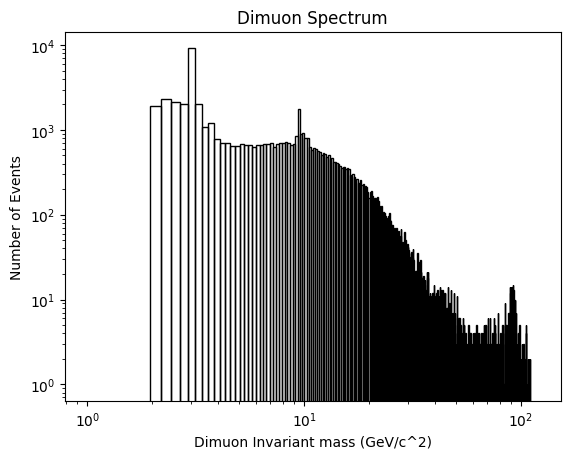

In [14]:
# Your code here
import matplotlib.pyplot as plt
import numpy as np


!pip install git+https://github.com/mattbellis/h5hep.git
!pip install git+https://github.com/mattbellis/particle_physics_simplified.git


import pps_tools as pps
import h5hep
pps.download_from_drive('dimuons_100k.hdf5')
infile = 'data/dimuons_100k.hdf5'
collisions = pps.get_collisions(infile,experiment='CMS',verbose=False)

invariant_masses = []
for event in collisions:
  muons = event['muons']
  n = len(muons)
  for i in range (n):
    for j in range (i+1, n):

      if muons[i]['q'] * muons[j]['q'] < 0:
        E_total = muons[i]['e'] + muons[j]['e']
        px_total = muons[i]['px'] + muons[j]['px']
        py_total = muons[i]['py'] + muons[j]['py']
        pz_total = muons[i]['pz'] + muons[j]['pz']
        m = np.sqrt(E_total**2 - px_total**2 - py_total**2 - pz_total**2)
        invariant_masses.append(m)


plt.hist(invariant_masses, bins=500, range=(1, 120), facecolor='none', edgecolor='black')
plt.xlabel("Dimuon Invariant mass (GeV/c^2)")
plt.ylabel("Number of Events")
plt.title("Dimuon Spectrum")
plt.yscale('log')
plt.xscale('log')
plt.show()

#### Comments

Depending on which file you ran over, you may see hints of particles below 20 GeV/c$^2$. It is possible you see signs of other particles at even higher energies. Plot your masses over a wide range of values, but then zoom in (change the plotting range) on different mass ranges to see if you can identify these particles.  

I would like you to make these 4 histograms *in 4 different ways* focusing on on different mass ranges. To look at these mass ranges, you'll want to use the `bins` and `range` options in the `plt.hist()` function.

* *Mass range 1*: 0 - 120
* *Mass range 2*: 2 - 4
* *Mass range 3*: 8 - 12
* *Mass range 4*: 70 - 120

Remember, you'll have 4 charge combinations for each of these histograms.

At the end, write up an interpretation of what you found.

***Hint!***. You may want to look up the following subatomic particles.

* $J/\psi$ meson
* $\Upsilon(1S)$ meson (also called the Upsilon)
* $Z$-boson

  Cloning https://github.com/mattbellis/h5hep.git to /tmp/pip-req-build-38_0abr8
  Running command git clone --filter=blob:none --quiet https://github.com/mattbellis/h5hep.git /tmp/pip-req-build-38_0abr8
  Resolved https://github.com/mattbellis/h5hep.git to commit d9adc7dc7f7e3a3ec60671c731bf74a5f83e4e30
  Preparing metadata (setup.py) ... done
  Cloning https://github.com/mattbellis/particle_physics_simplified.git to /tmp/pip-req-build-_jr94uye
  Running command git clone --filter=blob:none --quiet https://github.com/mattbellis/particle_physics_simplified.git /tmp/pip-req-build-_jr94uye
  Resolved https://github.com/mattbellis/particle_physics_simplified.git to commit 85ec828661b39c6c08caa7625a584a76f473ee2a
  Preparing metadata (setup.py) ... done

Building a simplified interface to the events...

Building the indices...
Built the indices!
Data is read in and input file is closed.
Reading in event  0
Reading in event  10000
Reading in event  20000
Reading in event  30000
Reading in e

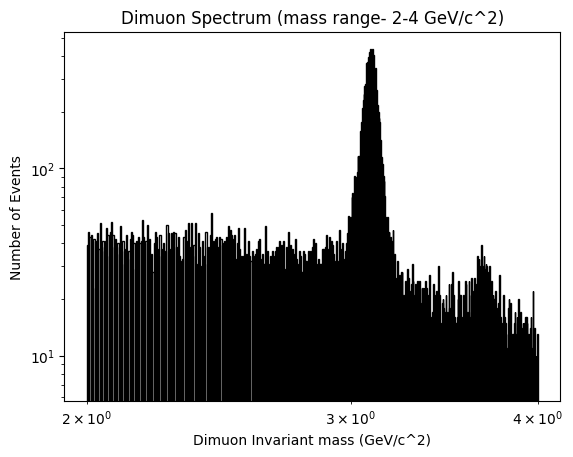

In [15]:
import matplotlib.pyplot as plt
import numpy as np


!pip install git+https://github.com/mattbellis/h5hep.git
!pip install git+https://github.com/mattbellis/particle_physics_simplified.git


import pps_tools as pps
import h5hep
pps.download_from_drive('dimuons_100k.hdf5')
infile = 'data/dimuons_100k.hdf5'
collisions = pps.get_collisions(infile,experiment='CMS',verbose=False)

invariant_masses = []
for event in collisions:
  muons = event['muons']
  n = len(muons)
  for i in range (n):
    for j in range (i+1, n):

      if muons[i]['q'] * muons[j]['q'] < 0:
        E_total = muons[i]['e'] + muons[j]['e']
        px_total = muons[i]['px'] + muons[j]['px']
        py_total = muons[i]['py'] + muons[j]['py']
        pz_total = muons[i]['pz'] + muons[j]['pz']
        m = np.sqrt(E_total**2 - px_total**2 - py_total**2 - pz_total**2)
        invariant_masses.append(m)


plt.hist(invariant_masses, bins=500, range=(2, 4), facecolor='none', edgecolor='black')
plt.xlabel("Dimuon Invariant mass (GeV/c^2)")
plt.ylabel("Number of Events")
plt.title("Dimuon Spectrum (mass range- 2-4 GeV/c^2)")
plt.yscale('log')
plt.xscale('log')
plt.show()

  Cloning https://github.com/mattbellis/h5hep.git to /tmp/pip-req-build-86bkrzpu
  Running command git clone --filter=blob:none --quiet https://github.com/mattbellis/h5hep.git /tmp/pip-req-build-86bkrzpu
  Resolved https://github.com/mattbellis/h5hep.git to commit d9adc7dc7f7e3a3ec60671c731bf74a5f83e4e30
  Preparing metadata (setup.py) ... done
  Cloning https://github.com/mattbellis/particle_physics_simplified.git to /tmp/pip-req-build-jwgjlr8v
  Running command git clone --filter=blob:none --quiet https://github.com/mattbellis/particle_physics_simplified.git /tmp/pip-req-build-jwgjlr8v
  Resolved https://github.com/mattbellis/particle_physics_simplified.git to commit 85ec828661b39c6c08caa7625a584a76f473ee2a
  Preparing metadata (setup.py) ... done

Building a simplified interface to the events...

Building the indices...
Built the indices!
Data is read in and input file is closed.
Reading in event  0
Reading in event  10000
Reading in event  20000
Reading in event  30000
Reading in e

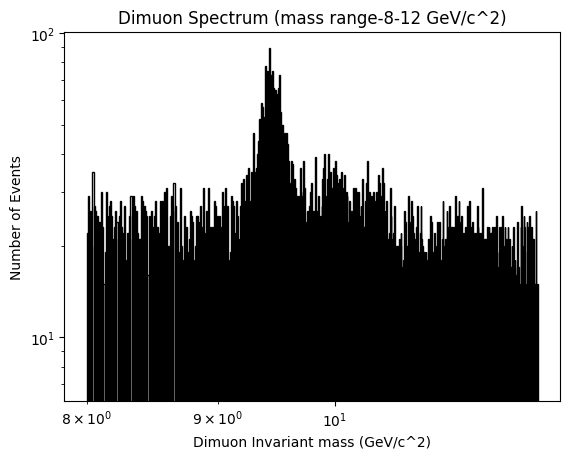

In [16]:
import matplotlib.pyplot as plt
import numpy as np


!pip install git+https://github.com/mattbellis/h5hep.git
!pip install git+https://github.com/mattbellis/particle_physics_simplified.git


import pps_tools as pps
import h5hep
pps.download_from_drive('dimuons_100k.hdf5')
infile = 'data/dimuons_100k.hdf5'
collisions = pps.get_collisions(infile,experiment='CMS',verbose=False)

invariant_masses = []
for event in collisions:
  muons = event['muons']
  n = len(muons)
  for i in range (n):
    for j in range (i+1, n):

      if muons[i]['q'] * muons[j]['q'] < 0:
        E_total = muons[i]['e'] + muons[j]['e']
        px_total = muons[i]['px'] + muons[j]['px']
        py_total = muons[i]['py'] + muons[j]['py']
        pz_total = muons[i]['pz'] + muons[j]['pz']
        m = np.sqrt(E_total**2 - px_total**2 - py_total**2 - pz_total**2)
        invariant_masses.append(m)


plt.hist(invariant_masses, bins=500, range=(8.0, 12.0), facecolor='none', edgecolor='black')
plt.xlabel("Dimuon Invariant mass (GeV/c^2)")
plt.ylabel("Number of Events")
plt.title("Dimuon Spectrum (mass range-8-12 GeV/c^2)")
plt.yscale('log')
plt.xscale('log')
plt.show()

  Cloning https://github.com/mattbellis/h5hep.git to /tmp/pip-req-build-ziuckp9l
  Running command git clone --filter=blob:none --quiet https://github.com/mattbellis/h5hep.git /tmp/pip-req-build-ziuckp9l
  Resolved https://github.com/mattbellis/h5hep.git to commit d9adc7dc7f7e3a3ec60671c731bf74a5f83e4e30
  Preparing metadata (setup.py) ... done
  Cloning https://github.com/mattbellis/particle_physics_simplified.git to /tmp/pip-req-build-ka473bfk
  Running command git clone --filter=blob:none --quiet https://github.com/mattbellis/particle_physics_simplified.git /tmp/pip-req-build-ka473bfk
  Resolved https://github.com/mattbellis/particle_physics_simplified.git to commit 85ec828661b39c6c08caa7625a584a76f473ee2a
  Preparing metadata (setup.py) ... done

Building a simplified interface to the events...

Building the indices...
Built the indices!
Data is read in and input file is closed.
Reading in event  0
Reading in event  10000
Reading in event  20000
Reading in event  30000
Reading in e

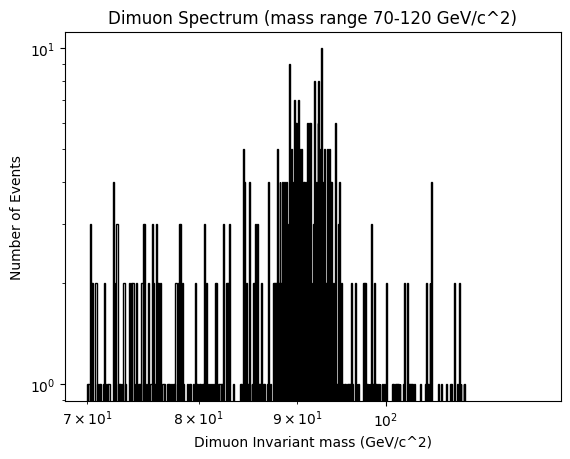

In [17]:
import matplotlib.pyplot as plt
import numpy as np


!pip install git+https://github.com/mattbellis/h5hep.git
!pip install git+https://github.com/mattbellis/particle_physics_simplified.git


import pps_tools as pps
import h5hep
pps.download_from_drive('dimuons_100k.hdf5')
infile = 'data/dimuons_100k.hdf5'
collisions = pps.get_collisions(infile,experiment='CMS',verbose=False)

invariant_masses = []
for event in collisions:
  muons = event['muons']
  n = len(muons)
  for i in range (n):
    for j in range (i+1, n):

      if muons[i]['q'] * muons[j]['q'] < 0:
        E_total = muons[i]['e'] + muons[j]['e']
        px_total = muons[i]['px'] + muons[j]['px']
        py_total = muons[i]['py'] + muons[j]['py']
        pz_total = muons[i]['pz'] + muons[j]['pz']
        m = np.sqrt(E_total**2 - px_total**2 - py_total**2 - pz_total**2)
        invariant_masses.append(m)


plt.hist(invariant_masses, bins=500, range=(70.0, 120.0), facecolor='none', edgecolor='black')
plt.xlabel("Dimuon Invariant mass (GeV/c^2)")
plt.ylabel("Number of Events")
plt.title("Dimuon Spectrum (mass range 70-120 GeV/c^2)")
plt.yscale('log')
plt.xscale('log')
plt.show()